## Gemini API Setup + plastic_classify_gemini

To use the Gemini API, you'll need an API key. If you don't already have one, create a key in [Google AI Studio](https://makersuite.google.com/app/apikey).

In Colab, add the key to the secrets manager under the "🔑" in the left panel. Give it the name `GOOGLE_API_KEY`. Then, we'll pass the key to the SDK:

In [ ]:
# Import the Python SDK
import google.generativeai as genai
# Used to securely store your API key
from google.colab import userdata

GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

In [ ]:
for m in genai.list_models():
  if 'generateContent' in m.supported_generation_methods:
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-

Next, we'll initialize the Generative Model. We will use the `gemini-pro-vision` model, which is capable of handling both text and image inputs.

In [ ]:
# Initialize a Gemini Vision model (using an available one from the list)
gemini_model = genai.GenerativeModel('gemini-3.1-flash-image') # Changed from 'gemini-3-pro-image'
print("Gemini Pro Vision model initialized.")

Gemini Pro Vision model initialized.


### `plastic_classify_gemini` function

This function is a variant of `plastic_classify` that uses the Gemini Pro Vision model for classification. It will take the cropped image and a prompt that includes the candidate labels.

In [ ]:
def plastic_classify_gemini(frame_path, clip_path, mask_path, candidate_labels):
    """
    Classifies a plastic object within an image using Gemini Pro Vision,
    using a mask to define the object's region.

    Args:
        frame_path (str): Full path to the input image frame.
        clip_path (str): Full path to the video clip (not used in this classification).
        mask_path (str): Full path to the mask image, defining the object's location.
        candidate_labels (list): A list of strings representing the possible categories.

    Returns:
        dict: The classification result (label) or an error message.
    """
    try:
        # Load the image
        image = Image.open(frame_path).convert("RGB")

        cropped_image = None
        if mask_path and os.path.exists(mask_path):
            bbox = get_bbox_from_mask(mask_path)
            if bbox:
                cropped_image = image.crop(bbox)
            else:
                print(f"No object found in mask for {mask_path}. Using full image.")
                cropped_image = image
        else:
            print(f"Mask path not provided or does not exist for {frame_path}. Using full image.")
            cropped_image = image

        if cropped_image is None:
            return {"error": "Failed to get image for classification."}

        # Prepare the prompt for Gemini
        labels_str = ", ".join([f'"{label}"' for label in candidate_labels])
        prompt = f"Classify the object in this image into one of the following categories: {labels_str}. Respond only with the chosen category name."

        # Perform classification with Gemini
        response = gemini_model.generate_content([prompt, cropped_image])

        # Extract the classification from Gemini's response
        # Gemini's response might need careful parsing depending on its exact format
        # For now, we'll assume it returns the category directly
        # A more robust solution might involve instructing Gemini to return JSON
        predicted_label = response.text.strip()

        # Basic check to see if the predicted label is one of the candidate labels
        # This is a simplification; a more advanced check would be needed
        if predicted_label in candidate_labels:
            return {'label': predicted_label, 'score': 1.0} # Assign a dummy score
        else:
            # Try to find a partial match or handle cases where Gemini adds extra words
            for label in candidate_labels:
                if label in predicted_label:
                    return {'label': label, 'score': 1.0}
            return {'label': predicted_label, 'score': 0.0, 'note': 'Label not in candidate list'}

    except FileNotFoundError:
        return {"error": f"Image file not found: {frame_path}"}
    except Exception as e:
        return {"error": f"An error occurred during Gemini classification for {frame_path}: {e}"}

### Re-running Classification using `plastic_classify_gemini`

In [ ]:
# Re-run the loop using plastic_classify_gemini

gemini_plastic_results = []

if test_limit is not None:
    print(f"Processing only the first {test_limit} files for Gemini classification...")
else:
    print("Processing all files for Gemini classification...")

for index, row in meta_df.iterrows():
    if test_limit is not None and index >= test_limit:
        print(f"Stopped after processing {test_limit} files for Gemini as per test_limit.")
        break

    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    clip_file_suffix = row['timestamp_clip_path'] # Not used by gemini_classify but passed for consistency

    full_frame_path = process_frame_path(
        frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root
    )

    full_mask_path = None
    if pd.notna(mask_file_suffix):
        full_mask_path = process_frame_path(
            mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root
        )

    # Note: full_clip_path is not used by plastic_classify_gemini, but provided for consistency
    result_gemini = plastic_classify_gemini(full_frame_path, None, full_mask_path, candidate_labels)
    gemini_plastic_results.append(result_gemini)

    if test_limit is None and (index + 1) % 100 == 0:
        print(f"Processed {index + 1} items with Gemini...")
    elif test_limit is not None:
        print(f"Processed item {index+1} with Gemini: {result_gemini}")

if test_limit is not None:
    print(f"Stopped after processing {len(gemini_plastic_results)} files for Gemini as per test_limit.")

print(f"\nTotal items processed by Gemini: {len(gemini_plastic_results)}")

Processing only the first 2 files for Gemini classification...


Processed item 1 with Gemini: {'error': 'An error occurred during Gemini classification for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000018.jpg: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-pro-vision:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-pro-vision is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.'}
Processed item 2 with Gemini: {'error': 'An error occurred during Gemini classification for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000019.jpg: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-pro-vision:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-pro-vision is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available mo

### Recalculate Success Rate for `plastic_classify_gemini`

In [ ]:
predicted_labels_gemini = []
for result in gemini_plastic_results:
    if 'label' in result:
        # The predicted label from Gemini should ideally be a direct category name
        # but we'll still strip to be safe and consistent.
        predicted_name_gemini = result['label'].strip()
        predicted_labels_gemini.append(predicted_name_gemini)
    else:
        predicted_labels_gemini.append(None) # Handle cases where classification failed

# Get the actual category names from meta_df, considering the test_limit
# We take as many actual category names as there are predicted labels.
actual_category_names_gemini = meta_df.loc[:len(predicted_labels_gemini)-1, 'category_name'].tolist()

# Compare predicted and actual labels for Gemini
correct_predictions_gemini = 0
for i in range(len(predicted_labels_gemini)):
    if predicted_labels_gemini[i] == actual_category_names_gemini[i]:
        correct_predictions_gemini += 1

# Calculate success rate for Gemini
total_predictions_gemini = len(predicted_labels_gemini)
success_rate_gemini = (correct_predictions_gemini / total_predictions_gemini) * 100 if total_predictions_gemini > 0 else 0

print(f"\nGemini Total predictions: {total_predictions_gemini}")
print(f"Gemini Correct predictions: {correct_predictions_gemini}")
print(f"Gemini Success Rate: {success_rate_gemini:.2f}%")


Gemini Total predictions: 2
Gemini Correct predictions: 0
Gemini Success Rate: 0.00%


### Classification using `plastic_classify_gemini`

In [ ]:
# Re-run the loop using plastic_classify_gemini

gemini_plastic_results = []

if test_limit is not None:
    print(f"Processing only the first {test_limit} files for Gemini classification...")
else:
    print("Processing all files for Gemini classification...")

for index, row in meta_df.iterrows():
    if test_limit is not None and index >= test_limit:
        print(f"Stopped after processing {test_limit} files for Gemini as per test_limit.")
        break

    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    clip_file_suffix = row['timestamp_clip_path'] # Not used by gemini_classify but passed for consistency

    full_frame_path = process_frame_path(
        frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root
    )

    full_mask_path = None
    if pd.notna(mask_file_suffix):
        full_mask_path = process_frame_path(
            mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root
        )

    # Note: full_clip_path is not used by plastic_classify_gemini, but provided for consistency
    result_gemini = plastic_classify_gemini(full_frame_path, None, full_mask_path, candidate_labels)
    gemini_plastic_results.append(result_gemini)

    if test_limit is None and (index + 1) % 100 == 0:
        print(f"Processed {index + 1} items with Gemini...")
    elif test_limit is not None:
        print(f"Processed item {index+1} with Gemini: {result_gemini}")

if test_limit is not None:
    print(f"Stopped after processing {len(gemini_plastic_results)} files for Gemini as per test_limit.")

print(f"\nTotal items processed by Gemini: {len(gemini_plastic_results)}")

Processing only the first 2 files for Gemini classification...


Processed item 1 with Gemini: {'error': 'An error occurred during Gemini classification for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000018.jpg: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-image:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3.1-flash-image\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-flash-image\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-flash-image\nPl

### Calculate Success Rate for `plastic_classify_gemini`

In [ ]:
predicted_labels_gemini = []
for result in gemini_plastic_results:
    if 'label' in result:
        # The predicted label from Gemini should ideally be a direct category name
        # but we'll still strip to be safe and consistent.
        predicted_name_gemini = result['label'].strip()
        predicted_labels_gemini.append(predicted_name_gemini)
    else:
        predicted_labels_gemini.append(None) # Handle cases where classification failed

# Get the actual category names from meta_df, considering the test_limit
# We take as many actual category names as there are predicted labels.
actual_category_names_gemini = meta_df.loc[:len(predicted_labels_gemini)-1, 'category_name'].tolist()

# Compare predicted and actual labels for Gemini
correct_predictions_gemini = 0
for i in range(len(predicted_labels_gemini)):
    if predicted_labels_gemini[i] == actual_category_names_gemini[i]:
        correct_predictions_gemini += 1

# Calculate success rate for Gemini
total_predictions_gemini = len(predicted_labels_gemini)
success_rate_gemini = (correct_predictions_gemini / total_predictions_gemini) * 100 if total_predictions_gemini > 0 else 0

print(f"\nGemini Total predictions: {total_predictions_gemini}")
print(f"Gemini Correct predictions: {correct_predictions_gemini}")
print(f"Gemini Success Rate: {success_rate_gemini:.2f}%")


Gemini Total predictions: 2
Gemini Correct predictions: 0
Gemini Success Rate: 0.00%


In [ ]:
# Install necessary libraries
!pip install transformers torch Pillow -qq

In [ ]:
from PIL import Image
import requests
from transformers import pipeline
import io
import numpy as np # Required for mask processing

# Initialize the zero-shot image classification pipeline
classifier = pipeline("zero-shot-image-classification", model="openai/clip-vit-base-patch32")
print("Zero-shot image classification pipeline loaded.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Zero-shot image classification pipeline loaded.


## Object Classification with Bounding Box using Hugging Face

This section demonstrates how to classify an object within an image, specified by a bounding box, against a list of descriptive categories using a zero-shot image classification model from Hugging Face.

In [1]:
# 1. Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. meta_df
import pandas as pd
import json
import os # Added os import

db_root = 'drive/MyDrive/camera1_plastics_shareable_dataset'
csv_file_path = f'{db_root}/camera1_plastics_meta2.csv'
original_external_root = '/media/jisha/E/trash_dataset/'
colab_equivalent_prefix = 'drive/MyDrive/'

try:
    meta_df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded '{csv_file_path}'")
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found.")
except pd.errors.EmptyDataError:
    print(f"Error: The file '{csv_file_path}' is empty.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

def process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root):
    """
    Processes a raw frame file suffix to construct a full, accessible frame path.

    Args:
        frame_file_suffix (str): The suffix or full path of the frame file.
        original_external_root (str): The original external root directory.
        colab_equivalent_prefix (str): The Colab equivalent prefix for paths.
        db_root (str): The root directory of the database.

    Returns:
        str: The full, processed path to the frame file.
    """
    # Process frame path
    if frame_file_suffix.startswith(original_external_root):
        frame_path_temp = frame_file_suffix.replace(original_external_root, colab_equivalent_prefix)
    else:
        frame_path_temp = frame_file_suffix

    if frame_path_temp.startswith(db_root):
        relative_part_frame = frame_path_temp[len(db_root):]
        if relative_part_frame.startswith('/') or relative_part_frame.startswith('\\'):
            relative_part_frame = relative_part_frame[1:]
        full_frame_path = os.path.join(db_root, relative_part_frame)
    else:
        full_frame_path = os.path.join(db_root, frame_path_temp)

    return full_frame_path

Mounted at /content/drive
Successfully loaded 'drive/MyDrive/camera1_plastics_shareable_dataset/camera1_plastics_meta2.csv'


### `plastic_classify` function

This function encapsulates the logic for loading an image, extracting a bounding box from a mask, cropping the image, and then classifying the cropped object using the pre-loaded zero-shot classifier and candidate labels.

In [5]:
def get_bbox_from_mask(mask_path):
    """
    Loads a mask image and returns a bounding box (left, upper, right, lower)
    of the non-zero pixels.
    """
    try:
        mask = Image.open(mask_path).convert('L') # Convert to grayscale
    except FileNotFoundError:
        print(f"Mask file not found: {mask_path}")
        return None
    except Exception as e:
        print(f"Error loading mask {mask_path}: {e}")
        return None

    mask_array = np.array(mask)

    # Find where the mask is active (non-zero pixels)
    active_pixels = np.argwhere(mask_array > 0)

    if active_pixels.size == 0:
        return None # No object found in mask

    # Get min/max coordinates
    min_y, min_x = active_pixels.min(axis=0)
    max_y, max_x = active_pixels.max(axis=0)

    # Bounding box format: (left, upper, right, lower) for PIL.Image.crop
    # np.argwhere gives (row, col) so (y, x). max_x + 1 and max_y + 1 are for inclusivity.
    bbox = (min_x, min_y, max_x + 1, max_y + 1)
    return bbox

def plastic_classify_clip(frame_path, clip_path, mask_path):
    """
    Classifies a plastic object within an image, using a mask to define the object's region.

    Args:
        frame_path (str): Full path to the input image frame.
        clip_path (str): Full path to the video clip (not used in this classification).
        mask_path (str): Full path to the mask image, defining the object's location.

    Returns:
        list: The top 5 classification results (label and score) or an error message.
    """
    try:
        # Load the image
        image = Image.open(frame_path).convert("RGB")

        cropped_image = None
        if mask_path and os.path.exists(mask_path): # Check if mask_path exists
            bbox = get_bbox_from_mask(mask_path)
            if bbox:
                cropped_image = image.crop(bbox)
            else:
                print(f"No object found in mask for {mask_path}. Classifying full image.")
                cropped_image = image # Fallback to full image if mask is empty
        else:
            print(f"Mask path not provided or does not exist for {frame_path}. Classifying full image.")
            cropped_image = image # Fallback to full image if no mask or mask not found

        if cropped_image is None:
            return {"error": "Failed to get image for classification."}

        # Perform classification
        # 'classifier' and 'candidate_labels' are assumed to be globally defined
        results = classifier(cropped_image, candidate_labels=candidate_labels)

        return results[:5] # Return the top 5 predictions
    except FileNotFoundError:
        return {"error": f"Image file not found: {frame_path}"}
    except Exception as e:
        return {"error": f"An error occurred during classification for {frame_path}: {e}"}

## Object Classification with SigLIP (Hugging Face)

This section introduces SigLIP, another zero-shot image classification model from Hugging Face, for comparing its performance against CLIP and Gemini.

In [6]:
from transformers import pipeline # Import pipeline here

# Initialize the zero-shot image classification pipeline for SigLIP
# Using a different model from the Hugging Face hub
siglip_classifier = pipeline("zero-shot-image-classification", model="google/siglip-base-patch16-224")
print("SigLIP zero-shot image classification pipeline loaded.")

def plastic_classify_siglip(frame_path, clip_path, mask_path):
    """
    Classifies a plastic object within an image, using a mask to define the object's region.

    Args:
        frame_path (str): Full path to the input image frame.
        clip_path (str): Full path to the video clip (not used in this classification).
        mask_path (str): Full path to the mask image, defining the object's location.

    Returns:
        list: The top 5 classification results (label and score) or an error message.
    """
    try:
        # Load the image
        image = Image.open(frame_path).convert("RGB")

        cropped_image = None
        if mask_path and os.path.exists(mask_path): # Check if mask_path exists
            bbox = get_bbox_from_mask(mask_path)
            if bbox:
                cropped_image = image.crop(bbox)
            else:
                print(f"No object found in mask for {mask_path}. Classifying full image.")
                cropped_image = image # Fallback to full image if mask is empty
        else:
            print(f"Mask path not provided or does not exist for {frame_path}. Classifying full image.")
            cropped_image = image # Fallback to full image if no mask or mask not found

        if cropped_image is None:
            return {"error": "Failed to get image for classification."}

        # Perform classification using the SigLIP classifier
        # 'siglip_classifier' and 'candidate_labels' are assumed to be globally defined
        results = siglip_classifier(cropped_image, candidate_labels=candidate_labels)

        return results[:5] # Return the top 5 predictions
    except FileNotFoundError:
        return {"error": f"Image file not found: {frame_path}"}
    except Exception as e:
        return {"error": f"An error occurred during classification for {frame_path}: {e}"}

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B /  813MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

...

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

SigLIP zero-shot image classification pipeline loaded.


In [ ]:
import json
import os
import pandas as pd
from transformers import pipeline
from PIL import Image # Required for Image.open in plastic_classify_clip
import numpy as np # Required for get_bbox_from_mask if called directly
from tqdm.notebook import tqdm # Import tqdm for progress bars

# --- Re-initialize dependencies for robustness ---
# 1. Path definitions and meta_df load
db_root = 'drive/MyDrive/camera1_plastics_shareable_dataset'
csv_file_path = f'{db_root}/camera1_plastics_meta2.csv'
original_external_root = '/media/jisha/E/trash_dataset/'
colab_equivalent_prefix = 'drive/MyDrive/'

try:
    meta_df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded '{csv_file_path}'")
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found.")
    meta_df = pd.DataFrame() # Initialize as empty to prevent further errors
except pd.errors.EmptyDataError:
    print(f"Error: The file '{csv_file_path}' is empty.")
    meta_df = pd.DataFrame() # Initialize as empty to prevent further errors
except Exception as e:
    print(f"An unexpected error occurred loading meta_df: {e}")

# 2. process_frame_path function
def process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root):
    """
    Processes a raw frame file suffix to construct a full, accessible frame path.

    Args:
        frame_file_suffix (str): The suffix or full path of the frame file.
        original_external_root (str): The original external root directory.
        colab_equivalent_prefix (str): The Colab equivalent prefix for paths.
        db_root (str): The root directory of the database.

    Returns:
        str: The full, processed path to the frame file.
    """
    # Process frame path
    if frame_file_suffix.startswith(original_external_root):
        frame_path_temp = frame_file_suffix.replace(original_external_root, colab_equivalent_prefix)
    else:
        frame_path_temp = frame_file_suffix

    if frame_path_temp.startswith(db_root):
        relative_part_frame = frame_path_temp[len(db_root):]
        if relative_part_frame.startswith('/') or relative_part_frame.startswith('\\'):
            relative_part_frame = relative_part_frame[1:]
        full_frame_path = os.path.join(db_root, relative_part_frame)
    else:
        full_frame_path = os.path.join(db_root, frame_path_temp)

    return full_frame_path

# 3. get_bbox_from_mask function (needed by plastic_classify_clip/siglip)
def get_bbox_from_mask(mask_path):
    """
    Loads a mask image and returns a bounding box (left, upper, right, lower)
    of the non-zero pixels.
    """
    try:
        mask = Image.open(mask_path).convert('L') # Convert to grayscale
    except FileNotFoundError:
        print(f"Mask file not found: {mask_path}")
        return None
    except Exception as e:
        print(f"Error loading mask {mask_path}: {e}")
        return None

    mask_array = np.array(mask)

    # Find where the mask is active (non-zero pixels)
    active_pixels = np.argwhere(mask_array > 0)

    if active_pixels.size == 0:
        return None # No object found in mask

    # Get min/max coordinates
    min_y, min_x = active_pixels.min(axis=0)
    max_y, max_x = active_pixels.max(axis=0)

    # Bounding box format: (left, upper, right, lower) for PIL.Image.crop
    # np.argwhere gives (row, col) so (y, x). max_x + 1 and max_y + 1 are for inclusivity.
    bbox = (min_x, min_y, max_x + 1, max_y + 1)
    return bbox


# 4. Initialize CLIP and SigLIP classifiers
classifier = pipeline("zero-shot-image-classification", model="openai/clip-vit-base-patch32")
print("CLIP zero-shot image classification pipeline loaded.")

siglip_classifier = pipeline("zero-shot-image-classification", model="google/siglip-base-patch16-224")
print("SigLIP zero-shot image classification pipeline loaded.")

# 5. Load labels from taxonomy (re-using logic for robustness)
json_file_path_labels = f'{db_root}/camera1_plastics_taxonomy.json'
try:
    with open(json_file_path_labels, 'r') as f:
        data_labels = json.load(f)
    if isinstance(data_labels, dict):
        df_labels = pd.DataFrame.from_dict(data_labels, orient='index')
    elif isinstance(data_labels, list):
        df_labels = pd.DataFrame(data_labels)
    else:
        print("JSON content is not in a recognized format for tabular display (list or dictionary).")
        df_labels = pd.DataFrame([data_labels])

    categories_list_labels = df_labels.loc['categories', 0]
    categories_df_labels = pd.DataFrame(categories_list_labels)

    full_labels = [f"{row['name']}. {row['description']}" for index, row in categories_df_labels.iterrows()]
    concise_labels = [row['name'] for index, row in categories_df_labels.iterrows()]
    # Initialize candidate_labels
    candidate_labels = full_labels
    print(f"Labels (full and concise) reloaded from: {json_file_path_labels}")
except FileNotFoundError:
    print(f"Error: The labels file '{json_file_path_labels}' was not found.")
    full_labels = []
    concise_labels = []
except Exception as e:
    print(f"An unexpected error occurred loading labels: {e}")

# 6. Define plastic_classify_clip function
def plastic_classify_clip(frame_path, clip_path, mask_path):
    """
    Classifies a plastic object within an image, using a mask to define the object's region.

    Args:
        frame_path (str): Full path to the input image frame.
        clip_path (str): Full path to the video clip (not used in this classification).
        mask_path (str): Full path to the mask image, defining the object's location.

    Returns:
        list: The top 5 classification results (label and score) or an error message.
    """
    try:
        # Load the image
        image = Image.open(frame_path).convert("RGB")

        cropped_image = None
        if mask_path and os.path.exists(mask_path): # Check if mask_path exists
            bbox = get_bbox_from_mask(mask_path)
            if bbox:
                cropped_image = image.crop(bbox)
            else:
                print(f"No object found in mask for {mask_path}. Classifying full image.")
                cropped_image = image # Fallback to full image if mask is empty
        else:
            print(f"Mask path not provided or does not exist for {frame_path}. Classifying full image.")
            cropped_image = image # Fallback to full image if no mask or mask not found

        if cropped_image is None:
            return {"error": "Failed to get image for classification."}

        # Perform classification
        # 'classifier' and 'candidate_labels' are assumed to be globally defined
        results = classifier(cropped_image, candidate_labels=candidate_labels)

        return results[:5] # Return the top 5 predictions
    except FileNotFoundError:
        return {"error": f"Image file not found: {frame_path}"}
    except Exception as e:
        return {"error": f"An error occurred during classification for {frame_path}: {e}"}

# 7. Define plastic_classify_siglip function
def plastic_classify_siglip(frame_path, clip_path, mask_path):
    """
    Classifies a plastic object within an image, using a mask to define the object's region.

    Args:
        frame_path (str): Full path to the input image frame.
        clip_path (str): Full path to the video clip (not used in this classification).
        mask_path (str): Full path to the mask image, defining the object's location.

    Returns:n        list: The top 5 classification results (label and score) or an error message.
    """
    try:
        # Load the image
        image = Image.open(frame_path).convert("RGB")

        cropped_image = None
        if mask_path and os.path.exists(mask_path): # Check if mask_path exists
            bbox = get_bbox_from_mask(mask_path)
            if bbox:
                cropped_image = image.crop(bbox)
            else:
                print(f"No object found in mask for {mask_path}. Classifying full image.")
                cropped_image = image # Fallback to full image if mask is empty
        else:
            print(f"Mask path not provided or does not exist for {frame_path}. Classifying full image.")
            cropped_image = image # Fallback to full image if no mask or mask not found

        if cropped_image is None:
            return {"error": "Failed to get image for classification."}

        # Perform classification using the SigLIP classifier
        # 'siglip_classifier' and 'candidate_labels' are assumed to be globally defined
        results = siglip_classifier(cropped_image, candidate_labels=candidate_labels)

        return results[:5] # Return the top 5 predictions
    except FileNotFoundError:
        return {"error": f"Image file not found: {frame_path}"}
    except Exception as e:
        return {"error": f"An error occurred during classification for {frame_path}: {e}"}


test_limit = None # Define test_limit at the beginning of the cell. Set to an int (e.g., 50) for testing, or None for all files.

print(f"Processing first {test_limit if test_limit is not None else 'all'} cropped images for CLIP and SigLIP with both label sets...")

# Define base directory for saving results
# Changed to a writable location within the Colab environment
classification_results_base_dir = os.path.join('/content/drive/MyDrive/csire_code', 'classification_results')
os.makedirs(classification_results_base_dir, exist_ok=True)
print(f"Saving classification results to: {classification_results_base_dir}")

# --- CLIP Classification with Full Labels ---
clip_full_labels_output_dir = os.path.join(classification_results_base_dir, 'clip_full_labels_top5') # New folder name
os.makedirs(clip_full_labels_output_dir, exist_ok=True)
print(f"Saving CLIP (Full Labels) results to: {clip_full_labels_output_dir}")

clip_results_full_labels = []
for index, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc="CLIP (Full Labels)"):
    if test_limit is not None and index >= test_limit:
        break
    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    full_frame_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)
    full_mask_path = process_frame_path(mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root) if pd.notna(mask_file_suffix) else None

    # The plastic_classify_clip function uses the global 'candidate_labels' variable.
    # We need to temporarily reassign 'candidate_labels' before each set of classifications.
    # Alternatively, modify plastic_classify_clip to accept candidate_labels as an argument.
    # Given the current function definition, we will temporarily reassign the global variable.
    global candidate_labels # Declare candidate_labels as global
    temp_candidate_labels = candidate_labels # Store current global value
    candidate_labels = full_labels # Assign full labels

    result = plastic_classify_clip(full_frame_path, None, full_mask_path)
    clip_results_full_labels.append(result)

    # Save result for this frame
    frame_unique_id = f"{row['gx_id']}_{os.path.basename(full_frame_path).replace('.jpg', '')}"
    output_filename = f"{frame_unique_id}.json"
    output_filepath = os.path.join(clip_full_labels_output_dir, output_filename)
    with open(output_filepath, 'w') as f:
        json.dump(result, f) # 'result' now contains top 5

    if test_limit is not None and index < 5: print(f"CLIP (Full Labels) item {index+1}: {result}")

# Calculate CLIP Success Rate (Full Labels) - using the top-1 prediction from the saved results
predicted_labels_clip_full = []
for result_list in clip_results_full_labels:
    if isinstance(result_list, list) and len(result_list) > 0 and 'label' in result_list[0]:
        predicted_labels_clip_full.append(result_list[0]['label'].split('.')[0].strip())
    else: predicted_labels_clip_full.append(None)
actual_category_names_clip_full = meta_df.loc[:len(predicted_labels_clip_full)-1, 'category_name'].tolist()
correct_predictions_clip_full = sum(1 for i in range(len(predicted_labels_clip_full)) if predicted_labels_clip_full[i] == actual_category_names_clip_full[i])
total_predictions_clip_full = len(predicted_labels_clip_full)
success_rate_clip_full = (correct_predictions_clip_full / total_predictions_clip_full) * 100 if total_predictions_clip_full > 0 else 0
print(f"\nCLIP (Full Labels) Success Rate: {success_rate_clip_full:.2f}%")


# --- CLIP Classification with Concise Labels ---
clip_concise_labels_output_dir = os.path.join(classification_results_base_dir, 'clip_concise_labels_top5') # New folder name
os.makedirs(clip_concise_labels_output_dir, exist_ok=True)
print(f"Saving CLIP (Concise Labels) results to: {clip_concise_labels_output_dir}")

clip_results_concise_labels = []
for index, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc="CLIP (Concise Labels)"):
    if test_limit is not None and index >= test_limit:
        break
    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    full_frame_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)
    full_mask_path = process_frame_path(mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root) if pd.notna(mask_file_suffix) else None

    # The plastic_classify_clip function uses the global 'candidate_labels' variable.
    # We need to temporarily reassign 'candidate_labels' before each set of classifications.
    # Alternatively, modify plastic_classify_clip to accept candidate_labels as an argument.
    # Given the current function definition, we will temporarily reassign the global variable.
    global candidate_labels # Declare candidate_labels as global
    temp_candidate_labels = candidate_labels # Store current global value
    candidate_labels = concise_labels # Assign concise labels

    result = plastic_classify_clip(full_frame_path, None, full_mask_path)
    clip_results_concise_labels.append(result)

    # Save result for this frame
    frame_unique_id = f"{row['gx_id']}_{os.path.basename(full_frame_path).replace('.jpg', '')}"
    output_filename = f"{frame_unique_id}.json"
    output_filepath = os.path.join(clip_concise_labels_output_dir, output_filename)
    with open(output_filepath, 'w') as f:
        json.dump(result, f) # 'result' now contains top 5

    if test_limit is not None and index < 5: print(f"CLIP (Concise Labels) item {index+1}: {result}")

# Calculate CLIP Success Rate (Concise Labels) - using the top-1 prediction from the saved results
predicted_labels_clip_concise = []
for result_list in clip_results_concise_labels:
    if isinstance(result_list, list) and len(result_list) > 0 and 'label' in result_list[0]:
        predicted_labels_clip_concise.append(result_list[0]['label'].split('.')[0].strip())
    else: predicted_labels_clip_concise.append(None)
actual_category_names_clip_concise = meta_df.loc[:len(predicted_labels_clip_concise)-1, 'category_name'].tolist()
correct_predictions_clip_concise = sum(1 for i in range(len(predicted_labels_clip_concise)) if predicted_labels_clip_concise[i] == actual_category_names_clip_concise[i])
total_predictions_clip_concise = len(predicted_labels_clip_concise)
success_rate_clip_concise = (correct_predictions_clip_concise / total_predictions_clip_concise) * 100 if total_predictions_clip_concise > 0 else 0
print(f"CLIP (Concise Labels) Success Rate: {success_rate_clip_concise:.2f}%")

# Restore global candidate_labels
candidate_labels = temp_candidate_labels


# --- SigLIP Classification with Full Labels ---
siglip_full_labels_output_dir = os.path.join(classification_results_base_dir, 'siglip_full_labels_top5') # New folder name
os.makedirs(siglip_full_labels_output_dir, exist_ok=True)
print(f"Saving SigLIP (Full Labels) results to: {siglip_full_labels_output_dir}")

siglip_results_full_labels = []
for index, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc="SigLIP (Full Labels)"):
    if test_limit is not None and index >= test_limit:
        break
    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    full_frame_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)
    full_mask_path = process_frame_path(mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root) if pd.notna(mask_file_suffix) else None

    global candidate_labels # Declare candidate_labels as global
    temp_candidate_labels = candidate_labels # Store current global value
    candidate_labels = full_labels # Assign full labels

    result_siglip = plastic_classify_siglip(full_frame_path, None, full_mask_path)
    siglip_results_full_labels.append(result_siglip)

    # Save result for this frame
    frame_unique_id = f"{row['gx_id']}_{os.path.basename(full_frame_path).replace('.jpg', '')}"
    output_filename = f"{frame_unique_id}.json"
    output_filepath = os.path.join(siglip_full_labels_output_dir, output_filename)
    with open(output_filepath, 'w') as f:
        json.dump(result_siglip, f) # 'result_siglip' now contains top 5

    if test_limit is not None and index < 5: print(f"SigLIP (Full Labels) item {index+1}: {result_siglip}")

# Calculate SigLIP Success Rate (Full Labels) - using the top-1 prediction from the saved results
predicted_labels_siglip_full = []
for result_list in siglip_results_full_labels:
    if isinstance(result_list, list) and len(result_list) > 0 and 'label' in result_list[0]:
        predicted_labels_siglip_full.append(result_list[0]['label'].split('.')[0].strip())
    else: predicted_labels_siglip_full.append(None)
actual_category_names_siglip_full = meta_df.loc[:len(predicted_labels_siglip_full)-1, 'category_name'].tolist()
correct_predictions_siglip_full = sum(1 for i in range(len(predicted_labels_siglip_full)) if predicted_labels_siglip_full[i] == actual_category_names_siglip_full[i])
total_predictions_siglip_full = len(predicted_labels_siglip_full)
success_rate_siglip_full = (correct_predictions_siglip_full / total_predictions_siglip_full) * 100 if total_predictions_siglip_full > 0 else 0
print(f"SigLIP (Full Labels) Success Rate: {success_rate_siglip_full:.2f}%")

# Restore global candidate_labels
candidate_labels = temp_candidate_labels


# --- SigLIP Classification with Concise Labels ---
siglip_concise_labels_output_dir = os.path.join(classification_results_base_dir, 'siglip_concise_labels_top5') # New folder name
os.makedirs(siglip_concise_labels_output_dir, exist_ok=True)
print(f"Saving SigLIP (Concise Labels) results to: {siglip_concise_labels_output_dir}")

siglip_results_concise_labels = []
for index, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc="SigLIP (Concise Labels)"):
    if test_limit is not None and index >= test_limit:
        break
    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    full_frame_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)
    full_mask_path = process_frame_path(mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root) if pd.notna(mask_file_suffix) else None

    global candidate_labels # Declare candidate_labels as global
    temp_candidate_labels = candidate_labels # Store current global value
    candidate_labels = concise_labels # Assign concise labels

    result_siglip = plastic_classify_siglip(full_frame_path, None, full_mask_path)
    siglip_results_concise_labels.append(result_siglip)

    # Save result for this frame
    frame_unique_id = f"{row['gx_id']}_{os.path.basename(full_frame_path).replace('.jpg', '')}"
    output_filename = f"{frame_unique_id}.json"
    output_filepath = os.path.join(siglip_concise_labels_output_dir, output_filename)
    with open(output_filepath, 'w') as f:
        json.dump(result_siglip, f) # 'result_siglip' now contains top 5

    if test_limit is not None and index < 5: print(f"SigLIP (Concise Labels) item {index+1}: {result_siglip}")

# Calculate SigLIP Success Rate (Concise Labels) - using the top-1 prediction from the saved results
predicted_labels_siglip_concise = []
for result_list in siglip_results_concise_labels:
    if isinstance(result_list, list) and len(result_list) > 0 and 'label' in result_list[0]:
        predicted_labels_siglip_concise.append(result_list[0]['label'].split('.')[0].strip())
    else: predicted_labels_siglip_concise.append(None)
actual_category_names_siglip_concise = meta_df.loc[:len(predicted_labels_siglip_concise)-1, 'category_name'].tolist()
correct_predictions_siglip_concise = sum(1 for i in range(len(predicted_labels_siglip_concise)) if predicted_labels_siglip_concise[i] == actual_category_names_siglip_concise[i])
total_predictions_siglip_concise = len(predicted_labels_siglip_concise)
success_rate_siglip_concise = (correct_predictions_siglip_concise / total_predictions_siglip_concise) * 100 if total_predictions_siglip_concise > 0 else 0
print(f"SigLIP (Concise Labels) Success Rate: {success_rate_siglip_concise:.2f}%")

# Restore global candidate_labels
candidate_labels = temp_candidate_labels

Successfully loaded 'drive/MyDrive/camera1_plastics_shareable_dataset/camera1_plastics_meta2.csv'


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP zero-shot image classification pipeline loaded.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP zero-shot image classification pipeline loaded.
Labels (full and concise) reloaded from: drive/MyDrive/camera1_plastics_shareable_dataset/camera1_plastics_taxonomy.json
Processing first all cropped images for CLIP and SigLIP with both label sets...
Saving classification results to: /content/drive/MyDrive/csire_code/classification_results
Saving CLIP (Full Labels) results to: /content/drive/MyDrive/csire_code/classification_results/clip_full_labels_top5


...

Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000591.jpg. Classifying full image.
Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX020023/GX020023__frame_000988.jpg. Classifying full image.
Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX020023/GX020023__frame_000991.jpg. Classifying full image.
Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX020023/GX020023__frame_000994.jpg. Classifying full image.

CLIP (Full Labels) Success Rate: 9.69%
Saving CLIP (Concise Labels) results to: /content/drive/MyDrive/csire_code/classification_results/clip_concise_labels_top5


CLIP (Concise Labels):   0%|          | 0/3538 [00:00<?, ?it/s]

Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000591.jpg. Classifying full image.
Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX020023/GX020023__frame_000988.jpg. Classifying full image.
Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX020023/GX020023__frame_000991.jpg. Classifying full image.
Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX020023/GX020023__frame_000994.jpg. Classifying full image.
CLIP (Concise Labels) Success Rate: 10.26%
Saving SigLIP (Full Labels) results to: /content/drive/MyDrive/csire_code/classification_results/siglip_full_labels_top5


SigLIP (Full Labels):   0%|          | 0/3538 [00:00<?, ?it/s]

Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000591.jpg. Classifying full image.


## Comprehensive Cropped Image Classification with Full and Concise Labels

This section runs CLIP and SigLIP classifications on cropped images with an increased `test_limit` (300). Each model is tested with both the `full_labels` (with descriptions) and `concise_labels` (names only) to understand the impact of label detail on classification accuracy.

## Combined Classification and Success Rate Calculation for CLIP and SigLIP

This cell runs both `plastic_classify_clip` and `plastic_classify_siglip` with the current `test_limit` and then calculates their respective success rates.

In [ ]:
import os
import numpy as np

test_limit = None # Change to None to process all files

if test_limit is not None:
    print(f"Processing only the first {test_limit} files for testing...")
else:
    print("Processing all files...")

print(f"Processing with test_limit = {test_limit} files for both CLIP and SigLIP...")

# --- CLIP Classification ---
plastic_results = []
for index, row in meta_df.iterrows():
    if test_limit is not None and index >= test_limit:
        break
    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    full_frame_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)
    full_mask_path = process_frame_path(mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root) if pd.notna(mask_file_suffix) else None
    result = plastic_classify_clip(full_frame_path, None, full_mask_path)
    plastic_results.append(result)
    if test_limit is not None: print(f"Processed item {index+1} with CLIP: {result}")

# Calculate CLIP Success Rate
predicted_labels_clip = []
for result in plastic_results:
    if 'label' in result: predicted_labels_clip.append(result['label'].split('.')[0].strip())
    else: predicted_labels_clip.append(None)
actual_category_names_clip = meta_df.loc[:len(predicted_labels_clip)-1, 'category_name'].tolist()
correct_predictions_clip = sum(1 for i in range(len(predicted_labels_clip)) if predicted_labels_clip[i] == actual_category_names_clip[i])
total_predictions_clip = len(predicted_labels_clip)
success_rate = (correct_predictions_clip / total_predictions_clip) * 100 if total_predictions_clip > 0 else 0

print(f"\nCLIP Total predictions: {total_predictions_clip}")
print(f"CLIP Correct predictions: {correct_predictions_clip}")
print(f"CLIP Success Rate: {success_rate:.2f}%")

# --- SigLIP Classification ---
siglip_plastic_results = []
for index, row in meta_df.iterrows():
    if test_limit is not None and index >= test_limit:
        break
    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    full_frame_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)
    full_mask_path = process_frame_path(mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root) if pd.notna(mask_file_suffix) else None
    result_siglip = plastic_classify_siglip(full_frame_path, None, full_mask_path)
    siglip_plastic_results.append(result_siglip)
    if test_limit is not None: print(f"Processed item {index+1} with SigLIP: {result_siglip}")

# Calculate SigLIP Success Rate
predicted_labels_siglip = []
for result in siglip_plastic_results:
    if 'label' in result: predicted_labels_siglip.append(result['label'].split('.')[0].strip())
    else: predicted_labels_siglip.append(None)
actual_category_names_siglip = meta_df.loc[:len(predicted_labels_siglip)-1, 'category_name'].tolist()
correct_predictions_siglip = sum(1 for i in range(len(predicted_labels_siglip)) if predicted_labels_siglip[i] == actual_category_names_siglip[i])
total_predictions_siglip = len(predicted_labels_siglip)
success_rate_siglip = (correct_predictions_siglip / total_predictions_siglip) * 100 if total_predictions_siglip > 0 else 0

print(f"\nSigLIP Total predictions: {total_predictions_siglip}")
print(f"SigLIP Correct predictions: {correct_predictions_siglip}")
print(f"SigLIP Success Rate: {success_rate_siglip:.2f}%")


Processing with test_limit = 10 files for both CLIP and SigLIP...
Processed item 1 with CLIP: {'score': 0.4266538918018341, 'label': 'Containers #1/Clamshells. Plastic containers or lids that are labelled as PETE, PET, or #1 (polyethylene terephthalate) without a screw-off lid.'}
Processed item 2 with CLIP: {'score': 0.3544619679450989, 'label': 'Plastic. '}
Processed item 3 with CLIP: {'score': 0.7231801748275757, 'label': 'Other Unnumbered Containers & Fragments. Any loose / unnumbered plastic lids, tops, caps, containers, or container fragments.'}
Processed item 4 with CLIP: {'score': 0.7201889157295227, 'label': 'Other Unnumbered Containers & Fragments. Any loose / unnumbered plastic lids, tops, caps, containers, or container fragments.'}
Processed item 5 with CLIP: {'score': 0.2141515612602234, 'label': 'Other Rigid/Bulky Plastics. Plastics that are the size of a 5-gallon bucket or larger.'}
Processed item 6 with CLIP: {'score': 0.2750967741012573, 'label': 'Containers #2 Natural.

## Updated Comparison of Success Rates (CLIP, Gemini, SigLIP)

### Visual Inspection: Cropped Images with Ground-Truth Labels

Let's display the cropped images that SigLIP processed, along with their ground-truth labels, to visually inspect the classification task.

Displaying the first 10 cropped images with their ground-truth labels:


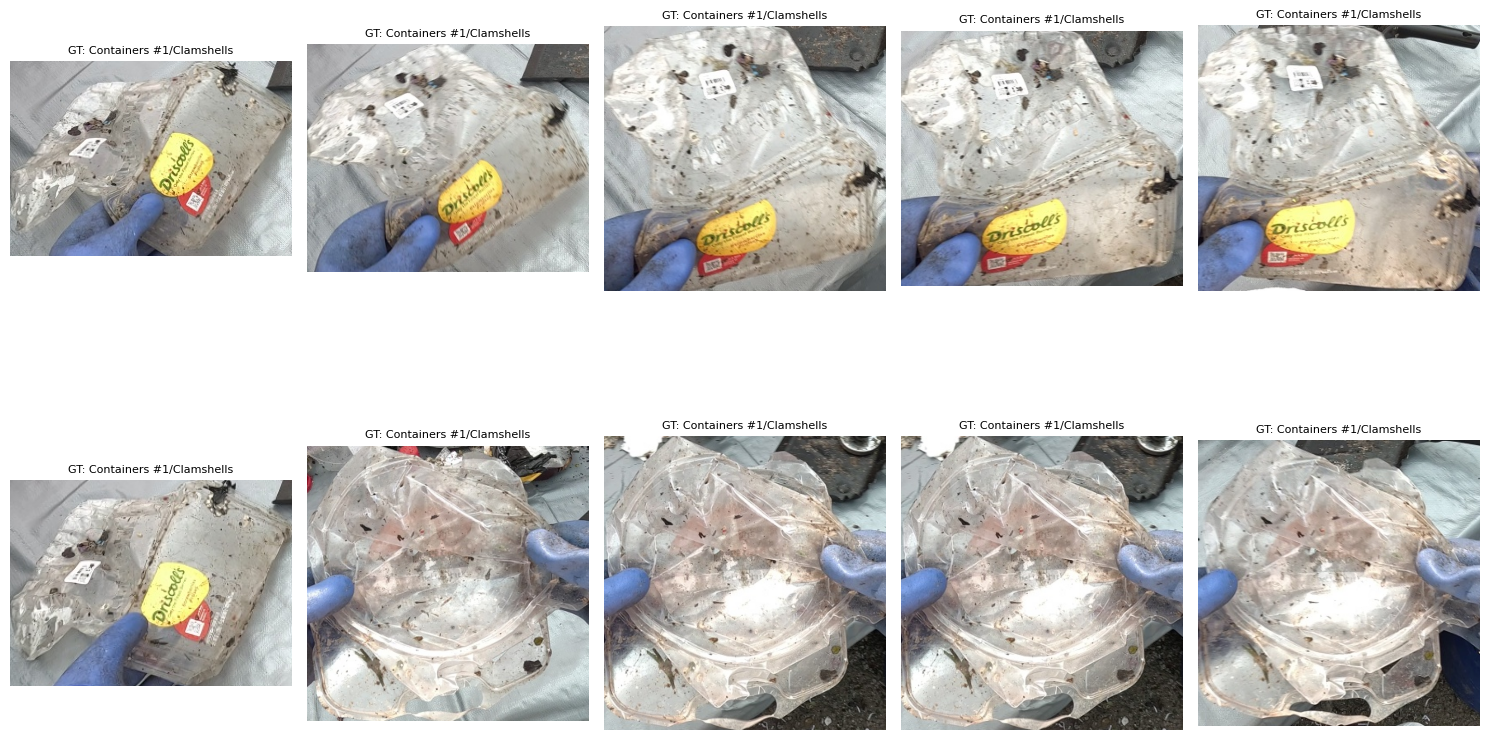

In [ ]:
import matplotlib.pyplot as plt

print(f"Displaying the first {test_limit} cropped images with their ground-truth labels:")

plt.figure(figsize=(15, 10))

for i in range(test_limit):
    row = meta_df.iloc[i]
    frame_file_suffix = row['copied_frame_path']
    mask_file_suffix = row['copied_mask_path']
    actual_category = row['category_name']

    full_frame_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)
    full_mask_path = process_frame_path(mask_file_suffix, original_external_root, colab_equivalent_prefix, db_root) if pd.notna(mask_file_suffix) else None

    try:
        image = Image.open(full_frame_path).convert("RGB")
        cropped_image = None

        if full_mask_path and os.path.exists(full_mask_path):
            bbox = get_bbox_from_mask(full_mask_path)
            if bbox:
                cropped_image = image.crop(bbox)
            else:
                cropped_image = image # Fallback to full image if mask is empty
        else:
            cropped_image = image # Fallback to full image if no mask or mask not found

        if cropped_image:
            plt.subplot(2, 5, i + 1) # Adjust subplot grid as needed
            plt.imshow(cropped_image)
            plt.title(f"GT: {actual_category}", fontsize=8)
            plt.axis('off')

    except FileNotFoundError:
        print(f"Image file not found for index {i}: {full_frame_path}")
    except Exception as e:
        print(f"Error processing image for index {i}: {e}")

plt.tight_layout()
plt.show()

## Full Image Classification (No Masking) and Visualization

This section runs CLIP and SigLIP classifications on the entire input images (without using object masks) and then visualizes these full images, subsampled by 50%, with their ground-truth labels.

In [ ]:
print(f"Processing with test_limit = {test_limit} files for full-image classification (no masks)...")

# --- CLIP Full Image Classification ---
plastic_results_full_image = []
for index, row in meta_df.iterrows():
    if test_limit is not None and index >= test_limit:
        break
    frame_file_suffix = row['copied_frame_path']
    full_frame_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)
    # Explicitly pass None for mask_path to use the full image
    result = plastic_classify_clip(full_frame_path, None, None)
    plastic_results_full_image.append(result)
    if test_limit is not None: print(f"Processed item {index+1} with CLIP (full image): {result}")

# Calculate CLIP Full Image Success Rate
predicted_labels_clip_full_image = []
for result in plastic_results_full_image:
    if 'label' in result: predicted_labels_clip_full_image.append(result['label'].split('.')[0].strip())
    else: predicted_labels_clip_full_image.append(None)
actual_category_names_clip_full_image = meta_df.loc[:len(predicted_labels_clip_full_image)-1, 'category_name'].tolist()
correct_predictions_clip_full_image = sum(1 for i in range(len(predicted_labels_clip_full_image)) if predicted_labels_clip_full_image[i] == actual_category_names_clip_full_image[i])
total_predictions_clip_full_image = len(predicted_labels_clip_full_image)
success_rate_clip_full_image = (correct_predictions_clip_full_image / total_predictions_clip_full_image) * 100 if total_predictions_clip_full_image > 0 else 0

print(f"\nCLIP (Full Image) Total predictions: {total_predictions_clip_full_image}")
print(f"CLIP (Full Image) Correct predictions: {correct_predictions_clip_full_image}")
print(f"CLIP (Full Image) Success Rate: {success_rate_clip_full_image:.2f}%")

# --- SigLIP Full Image Classification ---
siglip_plastic_results_full_image = []
for index, row in meta_df.iterrows():
    if test_limit is not None and index >= test_limit:
        break
    frame_file_suffix = row['copied_frame_path']
    full_frame_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)
    # Explicitly pass None for mask_path to use the full image
    result_siglip = plastic_classify_siglip(full_frame_path, None, None)
    siglip_plastic_results_full_image.append(result_siglip)
    if test_limit is not None: print(f"Processed item {index+1} with SigLIP (full image): {result_siglip}")

# Calculate SigLIP Full Image Success Rate
predicted_labels_siglip_full_image = []
for result in siglip_plastic_results_full_image:
    if 'label' in result: predicted_labels_siglip_full_image.append(result['label'].split('.')[0].strip())
    else: predicted_labels_siglip_full_image.append(None)
actual_category_names_siglip_full_image = meta_df.loc[:len(predicted_labels_siglip_full_image)-1, 'category_name'].tolist()
correct_predictions_siglip_full_image = sum(1 for i in range(len(predicted_labels_siglip_full_image)) if predicted_labels_siglip_full_image[i] == actual_category_names_siglip_full_image[i])
total_predictions_siglip_full_image = len(predicted_labels_siglip_full_image)
success_rate_siglip_full_image = (correct_predictions_siglip_full_image / total_predictions_siglip_full_image) * 100 if total_predictions_siglip_full_image > 0 else 0

print(f"\nSigLIP (Full Image) Total predictions: {total_predictions_siglip_full_image}")
print(f"SigLIP (Full Image) Correct predictions: {correct_predictions_siglip_full_image}")
print(f"SigLIP (Full Image) Success Rate: {success_rate_siglip_full_image:.2f}%")


Processing with test_limit = 10 files for full-image classification (no masks)...
Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000018.jpg. Classifying full image.
Processed item 1 with CLIP (full image): {'score': 0.5150933861732483, 'label': 'Other Unnumbered Containers & Fragments'}
Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000019.jpg. Classifying full image.
Processed item 2 with CLIP (full image): {'score': 0.7688289284706116, 'label': 'Other Unnumbered Containers & Fragments'}
Mask path not provided or does not exist for drive/MyDrive/camera1_plastics_shareable_dataset/frames/GX010023/GX010023__frame_000020.jpg. Classifying full image.
Processed item 3 with CLIP (full image): {'score': 0.9105145335197449, 'label': 'Other Unnumbered Containers & Fragments'}
Mask path not provided or does not exist for drive/MyDrive/came

### Visual Inspection: Full Images (Subsampled by 50%) with Ground-Truth Labels

Let's display the full input images, subsampled by 50%, with their ground-truth labels for visual inspection of the full-image classification task.

Displaying the first 10 full images (subsampled by 50%) with their ground-truth labels:


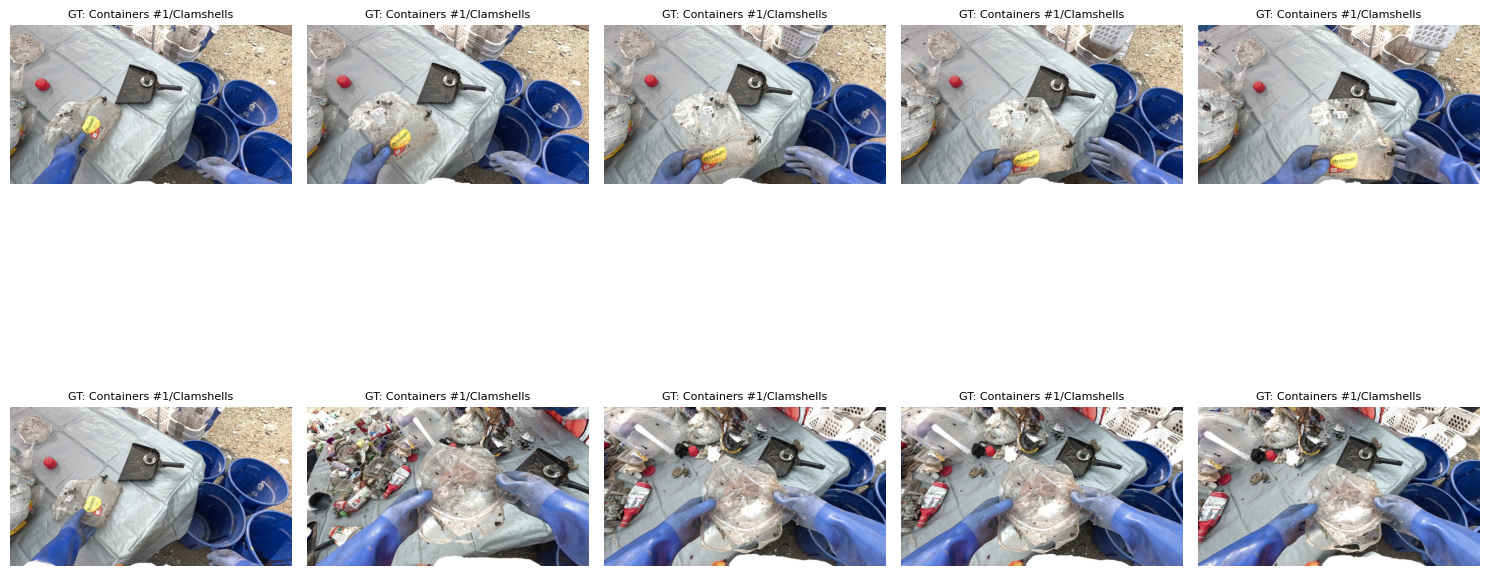

In [ ]:
import matplotlib.pyplot as plt

print(f"Displaying the first {test_limit} full images (subsampled by 50%) with their ground-truth labels:")

plt.figure(figsize=(15, 10))

for i in range(test_limit):
    row = meta_df.iloc[i]
    frame_file_suffix = row['copied_frame_path']
    actual_category = row['category_name']

    full_frame_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)

    try:
        image = Image.open(full_frame_path).convert("RGB")

        # Subsample image by 50%
        width, height = image.size
        subsampled_image = image.resize((width // 2, height // 2), Image.LANCZOS)

        plt.subplot(2, 5, i + 1) # Adjust subplot grid as needed
        plt.imshow(subsampled_image)
        plt.title(f"GT: {actual_category}", fontsize=8)
        plt.axis('off')

    except FileNotFoundError:
        print(f"Image file not found for index {i}: {full_frame_path}")
    except Exception as e:
        print(f"Error processing image for index {i}: {e}")

plt.tight_layout()
plt.show()

## Updated Comparison of Success Rates (CLIP, Gemini, SigLIP - Full Image vs. Cropped)

In [ ]:
print(f"Success Rate (Hugging Face CLIP - Cropped): {success_rate:.2f}%")
print(f"Success Rate (Hugging Face CLIP - Full Image): {success_rate_clip_full_image:.2f}%")
# Note: Gemini still has quota issues, so its success rate remains 0%
print(f"Success Rate (Gemini Pro Vision - Cropped): {success_rate_gemini:.2f}%")
print(f"Success Rate (Hugging Face SigLIP - Cropped): {success_rate_siglip:.2f}%")
print(f"Success Rate (Hugging Face SigLIP - Full Image): {success_rate_siglip_full_image:.2f}%")

Success Rate (Hugging Face CLIP - Cropped): 40.00%
Success Rate (Hugging Face CLIP - Full Image): 0.00%
Success Rate (Gemini Pro Vision - Cropped): 0.00%
Success Rate (Hugging Face SigLIP - Cropped): 0.00%
Success Rate (Hugging Face SigLIP - Full Image): 0.00%


## Recalculating Success Rates by Reading Saved JSON Files

This section demonstrates how to calculate the classification success rates by loading the previously saved JSON result files from the `classification_results_base_dir`.

This approach directly uses the persisted results, ensuring reproducibility and verifying the data saving process.

In [3]:
import os
import json
import pandas as pd
from tqdm.notebook import tqdm # Import tqdm for progress bars

# Re-initialize necessary variables and functions from cell hdDUBDnnLG6M
db_root = 'drive/MyDrive/camera1_plastics_shareable_dataset'
csv_file_path = f'{db_root}/camera1_plastics_meta2.csv'
original_external_root = '/media/jisha/E/trash_dataset/'
colab_equivalent_prefix = 'drive/MyDrive/'

try:
    meta_df = pd.read_csv(csv_file_path)
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found.")
    meta_df = pd.DataFrame() # Initialize as empty to prevent further errors
except pd.errors.EmptyDataError:
    print(f"Error: The file '{csv_file_path}' is empty.")
    meta_df = pd.DataFrame() # Initialize as empty to prevent further errors

def process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root):
    """
    Processes a raw frame file suffix to construct a full, accessible frame path.

    Args:
        frame_file_suffix (str): The suffix or full path of the frame file.
        original_external_root (str): The original external root directory.
        colab_equivalent_prefix (str): The Colab equivalent prefix for paths.
        db_root (str): The root directory of the database.

    Returns:
        str: The full, processed path to the frame file.
    """
    # Process frame path
    if frame_file_suffix.startswith(original_external_root):
        frame_path_temp = frame_file_suffix.replace(original_external_root, colab_equivalent_prefix)
    else:
        frame_path_temp = frame_file_suffix

    if frame_path_temp.startswith(db_root):
        relative_part_frame = frame_path_temp[len(db_root):]
        if relative_part_frame.startswith('/') or relative_part_frame.startswith('\\'):
            relative_part_frame = relative_part_frame[1:]
        full_frame_path = os.path.join(db_root, relative_part_frame)
    else:
        full_frame_path = os.path.join(db_root, frame_path_temp)

    return full_frame_path


classification_results_base_dir = os.path.join('/content/drive/MyDrive/csire_code', 'classification_results')

def calculate_success_rate_from_files(model_output_dir_name, meta_df_ref, top_n_values=[1, 3, 5]):
    """
    Calculates the success rate for top N predictions by reading classification results from JSON files.

    Args:
        model_output_dir_name (str): The name of the subdirectory containing JSON results (e.g., 'clip_full_labels_top5').
        meta_df_ref (pd.DataFrame): The metadata DataFrame containing ground truth labels.
        top_n_values (list): A list of integers (e.g., [1, 3, 5]) for which to calculate success rates.

    Returns:
        dict: A dictionary where keys are 'top_N' (e.g., 'top_1') and values are the success rates in percentage.
    """
    predicted_top_n_labels = {n: [] for n in top_n_values}
    actual_category_names = []

    results_dir = os.path.join(classification_results_base_dir, model_output_dir_name)

    if not os.path.exists(results_dir):
        print(f"Results directory not found: {results_dir}")
        return {f'top_{n}': 0.0 for n in top_n_values}

    # Iterate through meta_df to match with saved results
    for index, row in tqdm(meta_df_ref.iterrows(), total=len(meta_df_ref), desc=f"Processing {model_output_dir_name}"):
        # Reconstruct the expected filename based on how it was saved in cell 0092e582
        frame_file_suffix = row['copied_frame_path']
        processed_frame_full_path = process_frame_path(frame_file_suffix, original_external_root, colab_equivalent_prefix, db_root)
        frame_base_name = os.path.basename(processed_frame_full_path).replace('.jpg', '')
        frame_unique_id = f"{row['gx_id']}_{frame_base_name}"
        output_filename = f"{frame_unique_id}.json"
        output_filepath = os.path.join(results_dir, output_filename)

        if not os.path.exists(output_filepath):
            # This case might happen if test_limit was used during saving
            # or if the file was not saved for some reason. Skip.
            continue

        try:
            with open(output_filepath, 'r') as f:
                results_list = json.load(f)

            # Ensure results_list is a list of dicts with 'label'
            if isinstance(results_list, list) and all(isinstance(res, dict) and 'label' in res for res in results_list):
                all_predicted_labels = [res['label'].split('.')[0].strip() for res in results_list]

                for n in top_n_values:
                    # Check if the actual label is in the top N predictions
                    actual_label = row['category_name']
                    if actual_label in all_predicted_labels[:n]:
                        predicted_top_n_labels[n].append(True)
                    else:
                        predicted_top_n_labels[n].append(False)

                actual_category_names.append(actual_label) # Append actual label once per image

            else:
                print(f"Warning: Unexpected JSON format in {output_filepath}. Skipping for this image.")
                for n in top_n_values: predicted_top_n_labels[n].append(False)
                actual_category_names.append(row['category_name'])

        except json.JSONDecodeError:
            print(f"Error decoding JSON from {output_filepath}. Skipping.")
            for n in top_n_values: predicted_top_n_labels[n].append(False)
            actual_category_names.append(row['category_name'])
        except Exception as e:
            print(f"An error occurred while processing {output_filepath}: {e}. Skipping.")
            for n in top_n_values: predicted_top_n_labels[n].append(False)
            actual_category_names.append(row['category_name'])

    calculated_success_rates = {}
    for n in top_n_values:
        total_predictions = len(predicted_top_n_labels[n])
        correct_predictions = sum(predicted_top_n_labels[n])
        success_rate = (correct_predictions / total_predictions) * 100 if total_predictions > 0 else 0.0
        calculated_success_rates[f'top_{n}'] = success_rate

    return calculated_success_rates

print("Calculating success rates from saved JSON files...")

# CLIP Full Labels
success_rates_clip_full_from_files = calculate_success_rate_from_files('clip_full_labels_top5', meta_df)
print(f"\nSuccess Rates (CLIP - Full Labels, from files):")
for k, v in success_rates_clip_full_from_files.items():
    print(f"  {k}: {v:.2f}%")

# CLIP Concise Labels
success_rates_clip_concise_from_files = calculate_success_rate_from_files('clip_concise_labels_top5', meta_df)
print(f"\nSuccess Rates (CLIP - Concise Labels, from files):")
for k, v in success_rates_clip_concise_from_files.items():
    print(f"  {k}: {v:.2f}%")

# SigLIP Full Labels
success_rates_siglip_full_from_files = calculate_success_rate_from_files('siglip_full_labels_top5', meta_df)
print(f"\nSuccess Rates (SigLIP - Full Labels, from files):")
for k, v in success_rates_siglip_full_from_files.items():
    print(f"  {k}: {v:.2f}%")

# SigLIP Concise Labels
success_rates_siglip_concise_from_files = calculate_success_rate_from_files('siglip_concise_labels_top5', meta_df)
print(f"\nSuccess Rates (SigLIP - Concise Labels, from files):")
for k, v in success_rates_siglip_concise_from_files.items():
    print(f"  {k}: {v:.2f}%")

Calculating success rates from saved JSON files...


Processing clip_full_labels_top5:   0%|          | 0/3538 [00:00<?, ?it/s]


Success Rates (CLIP - Full Labels, from files):
  top_1: 9.95%
  top_3: 27.05%
  top_5: 40.31%


Processing clip_concise_labels_top5:   0%|          | 0/3538 [00:00<?, ?it/s]


Success Rates (CLIP - Concise Labels, from files):
  top_1: 10.43%
  top_3: 26.09%
  top_5: 38.44%


Processing siglip_full_labels_top5:   0%|          | 0/3538 [00:00<?, ?it/s]


Success Rates (SigLIP - Full Labels, from files):
  top_1: 2.91%
  top_3: 19.80%
  top_5: 36.61%
Results directory not found: /content/drive/MyDrive/csire_code/classification_results/siglip_concise_labels_top5

Success Rates (SigLIP - Concise Labels, from files):
  top_1: 0.00%
  top_3: 0.00%
  top_5: 0.00%


### Alternative: Multimodal Models (Gemini, Qwen-VL)

You also mentioned models like Gemini, Qwen, ChatGPT, and Claude. For multimodal tasks involving both image and text (like describing an object), models such as Google's Gemini Pro Vision or Qwen-VL could be used. These models can often take an image and a text prompt (e.g., "What is this object?") and provide a textual answer or directly classify based on a given set of options.

If you're interested in using **Gemini Pro Vision** for this task, let me know, and I can provide an example using the `google.generativeai` library. This would involve sending the image and a prompt (e.g., "Classify the object in the bounding box [x1, y1, x2, y2] into one of these categories: [list of categories]") to the Gemini API.